# FoCal data — quick tour

End-to-end example: open a ROOT run file, inspect what's inside, look at events, compute per-event features and distributions, then wrap everything in a PyTorch `DataLoader` and train a tiny autoencoder.

**Data shape:** each event is `(2 halves, 64 chips, 38 channels)` of ADC counts (`uint32`). Treat the two halves as channels of a 2D `(64, 38)` image and you can feed it straight to a CNN.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
print("project root:", PROJECT_ROOT)

ROOT_FILE = PROJECT_ROOT / "Data" / "Run0445.root"
assert ROOT_FILE.exists(), ROOT_FILE


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


## 1. Open the file & peek at the structure

ROOT files are key-value stores. The interesting thing here is the `TTree` called `data_tree`, with 18 fixed-size array branches per event.

In [2]:
f = uproot.open(ROOT_FILE)
tree = f["data_tree"]

print(f"n_events: {tree.num_entries}")
print("branches:")
for name in tree.keys():
    print(f"  {name:25s} {tree[name].typename}")

n_events: 32969
branches:
  timestamps_1              uint64_t[16]
  daqh_list_1               uint32_t[64]
  tc_list_1                 bool[2432]
  tp_list_1                 bool[2432]
  val0_list_1               uint32_t[2432]
  val1_list_1               uint32_t[2432]
  val2_list_1               uint32_t[2432]
  crc32_list_1              uint32_t[64]
  last_heartbeat_1          uint32_t[16]
  timestamps_0              uint64_t[16]
  daqh_list_0               uint32_t[64]
  tc_list_0                 bool[2432]
  tp_list_0                 bool[2432]
  val0_list_0               uint32_t[2432]
  val1_list_0               uint32_t[2432]
  val2_list_0               uint32_t[2432]
  crc32_list_0              uint32_t[64]
  last_heartbeat_0          uint32_t[16]


## 2. Load ADC values into one tensor

Stack both halves into shape `(N, 2, 64, 38)` — already in PyTorch's `(N, C, H, W)` convention.

In [3]:
val0 = np.stack([
    tree["val0_list_0"].array(library="np").reshape(-1, 64, 38),
    tree["val0_list_1"].array(library="np").reshape(-1, 64, 38),
], axis=1)  # (events, half, chip, channel)

print("shape:", val0.shape)
print("dtype:", val0.dtype)
print("memory:", val0.nbytes / 1e6, "MB")

shape: (32969, 2, 64, 38)
dtype: uint32
memory: 641.444864 MB


## 3. Basic statistics

Sanity-check the numbers before doing anything fancy.

In [4]:
print(f"min / max:        {val0.min()} / {val0.max()}")
print(f"mean ADC:         {val0.mean():.2f}")
print(f"median ADC:       {np.median(val0):.2f}")
print(f"nonzero fraction: {(val0 > 0).mean():.4f}")
print(f"saturated (max):  {(val0 == val0.max()).mean():.6f}")

min / max:        0 / 1023
mean ADC:         111.90
median ADC:       97.00
nonzero fraction: 0.9693
saturated (max):  0.008161


## 4. Per-channel pedestal view

Collapse the event axis to get a per-channel mean and std. Dead channels show up as flat zero; noisy channels show up as high std.

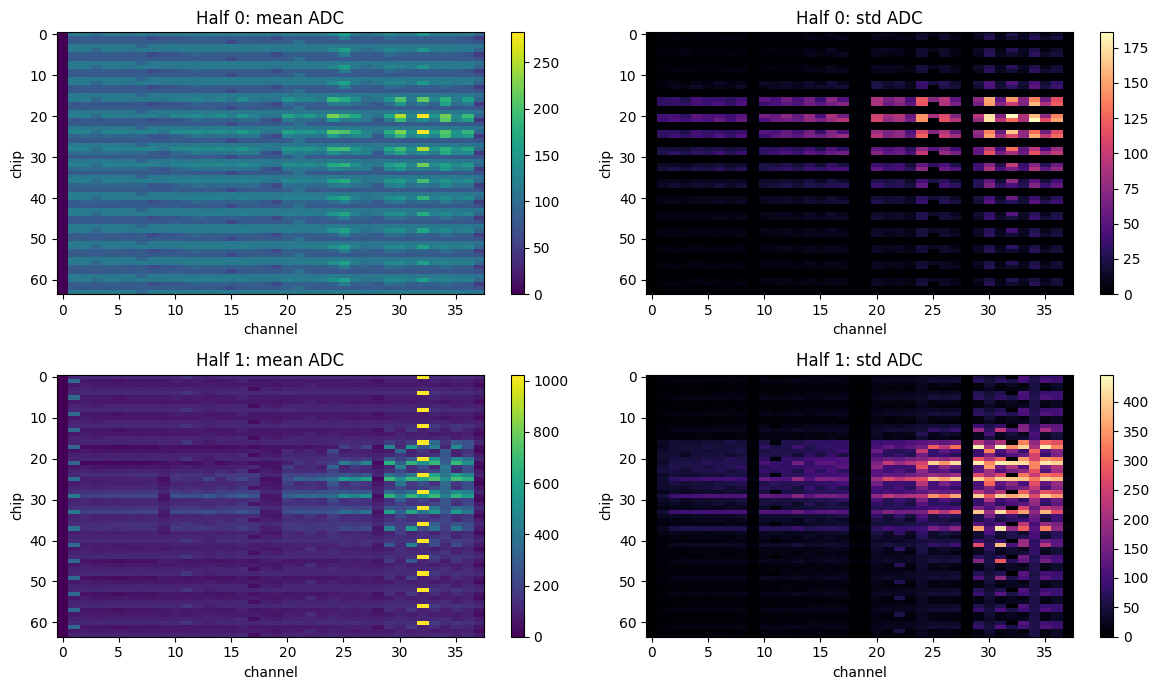

In [5]:
mean_per_ch = val0.mean(axis=0)  # (2, 64, 38)
std_per_ch  = val0.std(axis=0)

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
for h in range(2):
    im0 = ax[h, 0].imshow(mean_per_ch[h], aspect="auto", cmap="viridis")
    ax[h, 0].set_title(f"Half {h}: mean ADC")
    ax[h, 0].set_xlabel("channel"); ax[h, 0].set_ylabel("chip")
    plt.colorbar(im0, ax=ax[h, 0])

    im1 = ax[h, 1].imshow(std_per_ch[h], aspect="auto", cmap="magma")
    ax[h, 1].set_title(f"Half {h}: std ADC")
    ax[h, 1].set_xlabel("channel"); ax[h, 1].set_ylabel("chip")
    plt.colorbar(im1, ax=ax[h, 1])
plt.tight_layout(); plt.show()

## 5. Single-event displays

Pick a handful of events and look at them as `(chip × channel)` heatmaps. Picking the *highest-energy* events tends to be more informative than the first few.

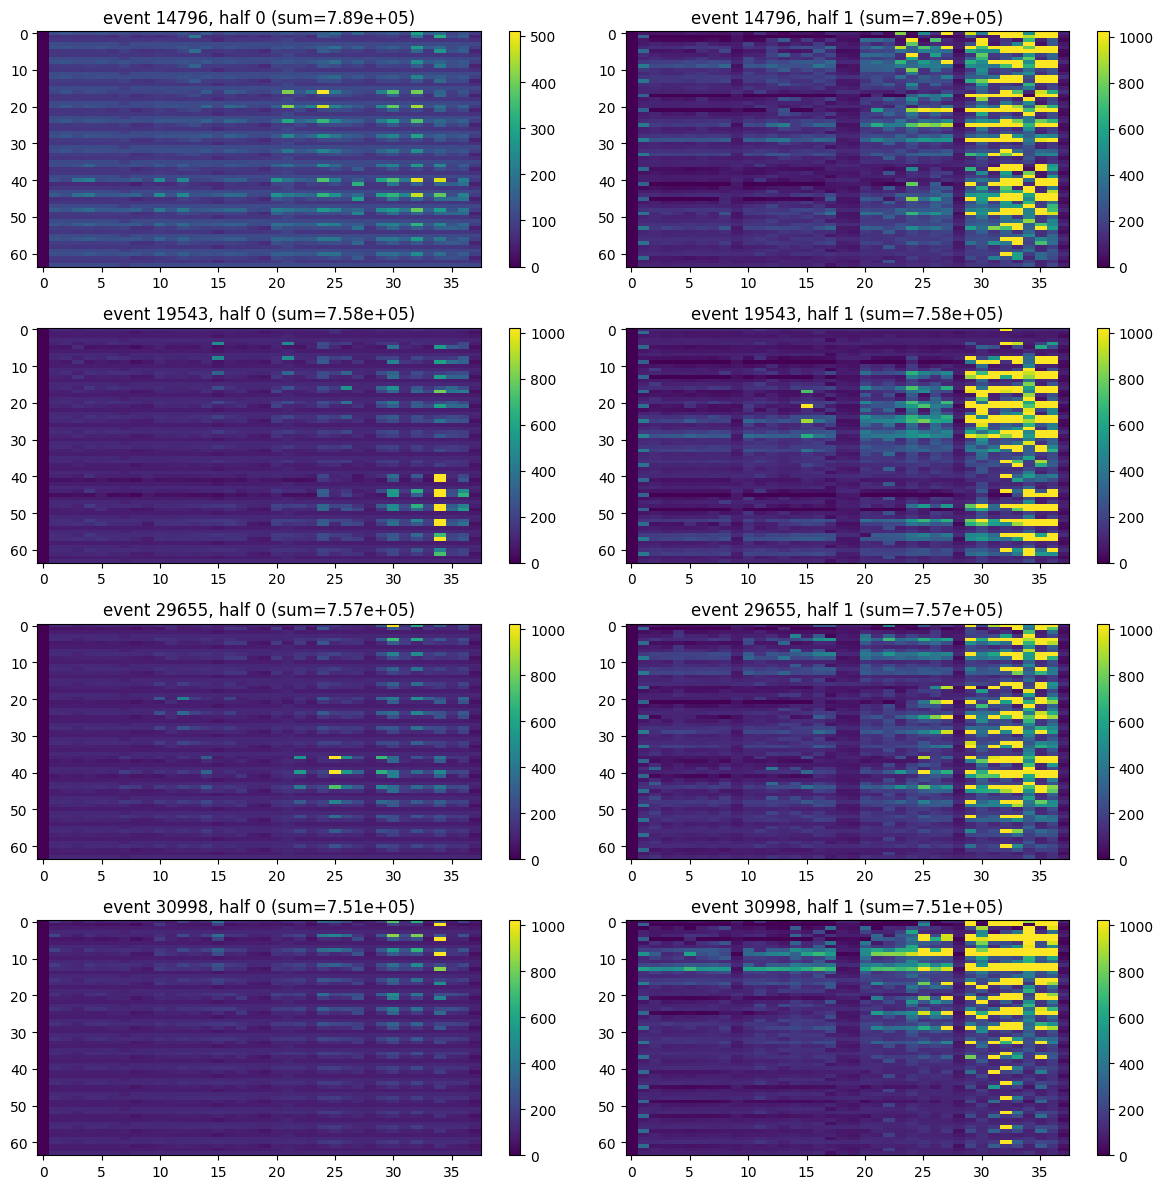

In [6]:
event_sum = val0.sum(axis=(1, 2, 3))
top_events = np.argsort(event_sum)[-4:][::-1]  # 4 biggest events

fig, ax = plt.subplots(4, 2, figsize=(12, 12))
for row, ev in enumerate(top_events):
    for h in range(2):
        im = ax[row, h].imshow(val0[ev, h], aspect="auto", cmap="viridis")
        ax[row, h].set_title(f"event {ev}, half {h} (sum={event_sum[ev]:.2e})")
        plt.colorbar(im, ax=ax[row, h])
plt.tight_layout(); plt.show()

## 6. Per-event features

Reduce each `(2, 64, 38)` event to a handful of scalars — useful for cuts, for plotting distributions, and as a sanity baseline for any model later.

In [7]:
THRESHOLD = 100  # ADC count above which we call a channel "hit" — tune to your detector

event_sum   = val0.sum(axis=(1, 2, 3)).astype(np.float64)
event_max   = val0.max(axis=(1, 2, 3))
event_mean  = val0.mean(axis=(1, 2, 3))
event_nhits = (val0 > THRESHOLD).sum(axis=(1, 2, 3))

# center-of-mass (chip, channel) of the energy, useful for shower position
energy_2d = val0.sum(axis=1).astype(np.float64)  # (N, 64, 38), sum over halves
chip_idx   = np.arange(64)[None, :, None]
ch_idx     = np.arange(38)[None, None, :]
total      = energy_2d.sum(axis=(1, 2)) + 1e-9
com_chip   = (energy_2d * chip_idx).sum(axis=(1, 2)) / total
com_ch     = (energy_2d * ch_idx  ).sum(axis=(1, 2)) / total

print(f"event_sum  range: {event_sum.min():.2e} → {event_sum.max():.2e}")
print(f"event_nhits avg:  {event_nhits.mean():.1f}")
print(f"COM chip range:   {com_chip.min():.1f} → {com_chip.max():.1f}")

event_sum  range: 4.53e+05 → 7.89e+05
event_nhits avg:  2299.8
COM chip range:   26.1 → 35.4


## 7. Distributions

Histograms of the event-level features. Use a log y-axis — detector data is almost always heavy-tailed.

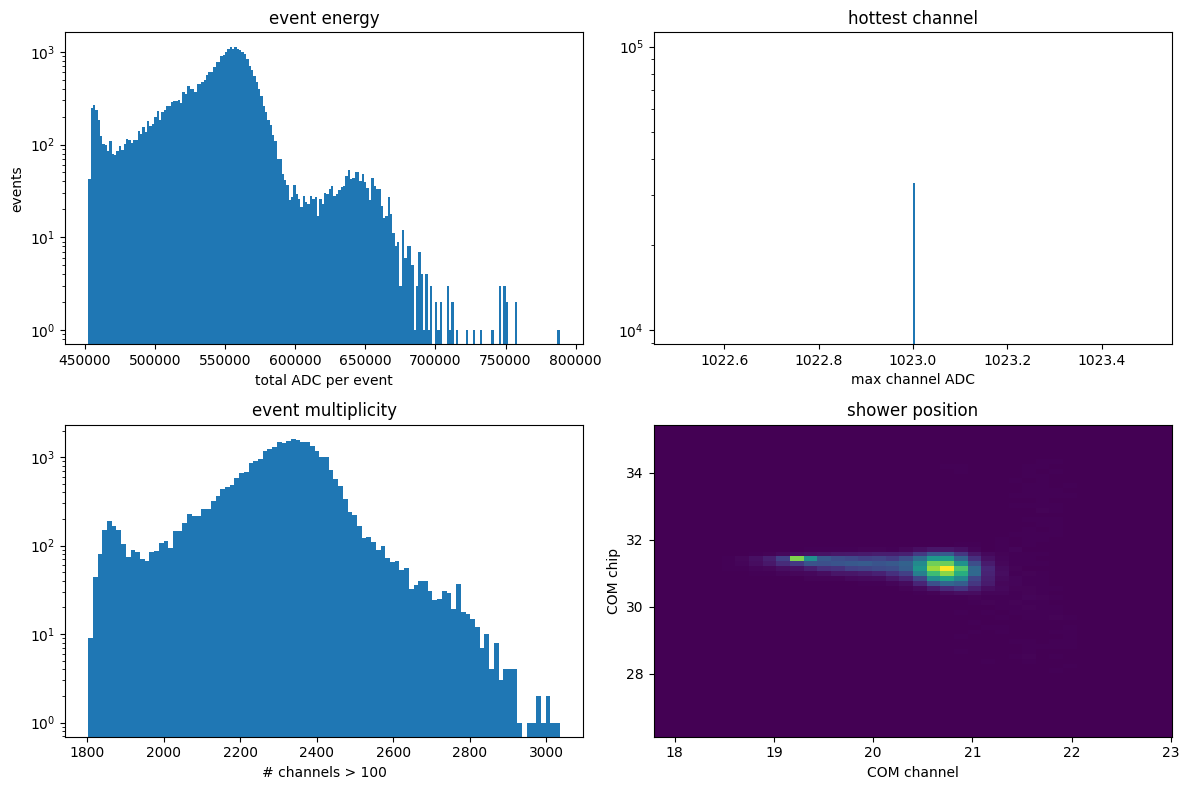

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].hist(event_sum, bins=200, log=True)
ax[0, 0].set_xlabel("total ADC per event"); ax[0, 0].set_ylabel("events")
ax[0, 0].set_title("event energy")

ax[0, 1].hist(event_max, bins=200, log=True)
ax[0, 1].set_xlabel("max channel ADC"); ax[0, 1].set_title("hottest channel")

ax[1, 0].hist(event_nhits, bins=100, log=True)
ax[1, 0].set_xlabel(f"# channels > {THRESHOLD}"); ax[1, 0].set_title("event multiplicity")

ax[1, 1].hist2d(com_ch, com_chip, bins=[38, 64])
ax[1, 1].set_xlabel("COM channel"); ax[1, 1].set_ylabel("COM chip")
ax[1, 1].set_title("shower position")
plt.tight_layout(); plt.show()

## 8. Channel-level distribution

Sometimes you want to see how *one* channel behaves across all events — e.g., to find dead, noisy, or saturating channels.

loudest channel: half=1, chip=0, channel=32


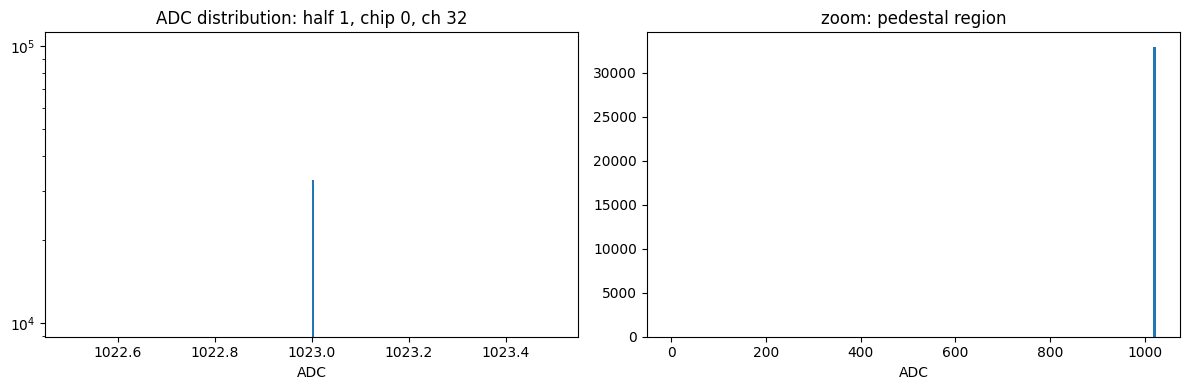

In [9]:
# pick the loudest channel as an example
h, chip, ch = np.unravel_index(np.argmax(mean_per_ch), mean_per_ch.shape)
print(f"loudest channel: half={h}, chip={chip}, channel={ch}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(val0[:, h, chip, ch], bins=200, log=True)
ax[0].set_title(f"ADC distribution: half {h}, chip {chip}, ch {ch}")
ax[0].set_xlabel("ADC")

# zoom in on the pedestal region
pedestal_max = int(np.percentile(val0[:, h, chip, ch], 95))
ax[1].hist(val0[:, h, chip, ch], bins=200, range=(0, pedestal_max))
ax[1].set_title("zoom: pedestal region"); ax[1].set_xlabel("ADC")
plt.tight_layout(); plt.show()

## 9. PyTorch `Dataset` + `DataLoader`

Wrap the array in a `Dataset` so we can shuffle, batch, and train. **Important detail:** estimate the pedestal mean/std from *quiet* events only (bottom-50% by total ADC). Including loud events inflates the per-channel std on hot chips, which makes the normalization push their signal back down — exactly what we don't want. The model should *see* the signal as a deviation from the noise baseline.


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

# Recompute pedestal from quiet events only (avoids signal events biasing std upward)
quiet_mask = event_sum < np.percentile(event_sum, 50)
mean_q = val0[quiet_mask].mean(axis=0).astype(np.float32)
std_q  = val0[quiet_mask].std(axis=0).astype(np.float32)
print(f"quiet events used for pedestal: {quiet_mask.sum()} / {len(val0)}")
print(f"avg per-channel std  -- all events: {std_per_ch.mean():.2f}   quiet only: {std_q.mean():.2f}")

class FoCalEvents(Dataset):
    def __init__(self, x, mean, std):
        # cast uint32 -> float32 once; normalize per-channel
        self.x = ((x.astype(np.float32) - mean) / (std + 1e-3)).astype(np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return torch.from_numpy(self.x[i])  # (2, 64, 38)

ds = FoCalEvents(val0, mean_q, std_q)
n_train = int(0.8 * len(ds))
n_val   = len(ds) - n_train
train_ds, val_ds = random_split(ds, [n_train, n_val], generator=torch.Generator().manual_seed(0))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("batch shape:", batch.shape, "dtype:", batch.dtype)
print("train:", len(train_ds), "val:", len(val_ds))


quiet events used for pedestal: 16482 / 32969
avg per-channel std  -- all events: 31.60   quiet only: 29.56
batch shape: torch.Size([128, 2, 64, 38]) dtype: torch.float32
train: 26375 val: 6594


## 10. A convolutional autoencoder with a *spatial* bottleneck

Two changes from before:

- **No flatten/FC at the bottleneck.** The latent stays as a small spatial tensor `(16, 10, 16)` -- a coarse "thumbnail" of the event. Conv layers preserve *where* information all the way through, so the decoder doesn't have to re-learn position from a flat vector.
- **Real compression ratio**: 4864 input -> 2560 latent (~1.9x). Honest bottleneck without throwing away spatial structure.

Same `model(x) -> (x_hat, z)` interface; `z` is now `(B, 16, 10, 16)` so flatten it if you want a feature vector.


In [11]:
import torch.nn as nn

class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: (2,64,38) -> (16,64,38) -> (32,32,19) -> (16,16,10)
        self.enc = nn.Sequential(
            nn.Conv2d(2,  16, 3, padding=1),                 nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),       nn.ReLU(),
            nn.Conv2d(32, 16, 3, stride=2, padding=1),       nn.ReLU(),
        )
        # Decoder: mirror
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(16, 32, 3, stride=2, padding=1, output_padding=(1, 0)), nn.ReLU(),  # 16x10 -> 32x19
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=(1, 1)), nn.ReLU(),  # 32x19 -> 64x38
            nn.Conv2d(16, 2, 3, padding=1),
        )

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model = ConvAE().to(device)

# quick shape check
with torch.no_grad():
    dummy = torch.zeros(2, 2, 64, 38, device=device)
    out, z = model(dummy)
    assert out.shape == dummy.shape
    print("latent shape:", z.shape, "(spatial, not flat)")

print(model)
print("device:", device, "params:", sum(p.numel() for p in model.parameters()))


latent shape: torch.Size([2, 16, 16, 10]) (spatial, not flat)
ConvAE(
  (enc): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (dec): Sequential(
    (0): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 0))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)
device: mps params: 19122


## 11. Train

Switch the loss to **L1** (mean absolute error). MSE penalizes large per-pixel errors quadratically, which pushes the model toward smooth/blurry outputs. L1 is more forgiving of large but rare errors -- so sparse hits get reproduced more sharply.


epoch 1/25  train L1=0.5200  val L1=0.4828
epoch 2/25  train L1=0.4607  val L1=0.4460
epoch 3/25  train L1=0.4275  val L1=0.4122
epoch 4/25  train L1=0.3954  val L1=0.3828
epoch 5/25  train L1=0.3730  val L1=0.3681
epoch 6/25  train L1=0.3567  val L1=0.3508
epoch 7/25  train L1=0.3446  val L1=0.3427
epoch 8/25  train L1=0.3375  val L1=0.3367
epoch 9/25  train L1=0.3324  val L1=0.3319
epoch 10/25  train L1=0.3284  val L1=0.3382
epoch 11/25  train L1=0.3253  val L1=0.3247
epoch 12/25  train L1=0.3224  val L1=0.3227
epoch 13/25  train L1=0.3199  val L1=0.3279
epoch 14/25  train L1=0.3179  val L1=0.3186
epoch 15/25  train L1=0.3159  val L1=0.3161
epoch 16/25  train L1=0.3142  val L1=0.3174
epoch 17/25  train L1=0.3126  val L1=0.3166
epoch 18/25  train L1=0.3115  val L1=0.3180
epoch 19/25  train L1=0.3100  val L1=0.3137
epoch 20/25  train L1=0.3128  val L1=0.3159
epoch 21/25  train L1=0.3085  val L1=0.3083
epoch 22/25  train L1=0.3073  val L1=0.3095
epoch 23/25  train L1=0.3120  val L1=0.31

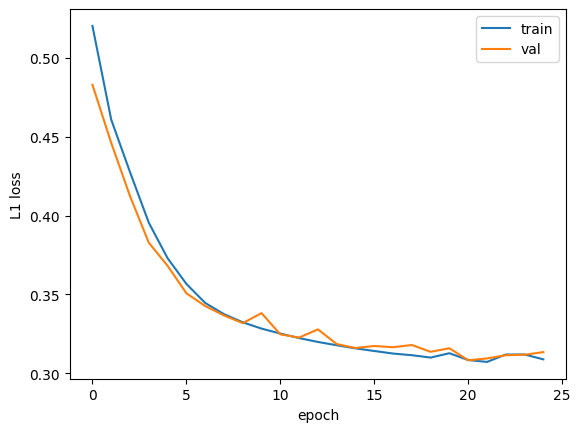

In [12]:
EPOCHS = 25
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()  # was MSELoss; L1 keeps sparse hits sharper

history = {"train": [], "val": []}
for epoch in range(EPOCHS):
    model.train()
    tr_loss = 0.0
    for x in train_loader:
        x = x.to(device)
        x_hat, _ = model(x)
        loss = loss_fn(x_hat, x)
        opt.zero_grad(); loss.backward(); opt.step()
        tr_loss += loss.item() * x.size(0)
    tr_loss /= len(train_ds)

    model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            x_hat, _ = model(x)
            va_loss += loss_fn(x_hat, x).item() * x.size(0)
    va_loss /= len(val_ds)

    history["train"].append(tr_loss); history["val"].append(va_loss)
    print(f"epoch {epoch+1}/{EPOCHS}  train L1={tr_loss:.4f}  val L1={va_loss:.4f}")

plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("epoch"); plt.ylabel("L1 loss"); plt.legend(); plt.show()


## 12. Look at reconstructions

The point of an autoencoder isn't the loss number — it's whether the reconstructions are recognizable. Compare input vs output for a few validation events.

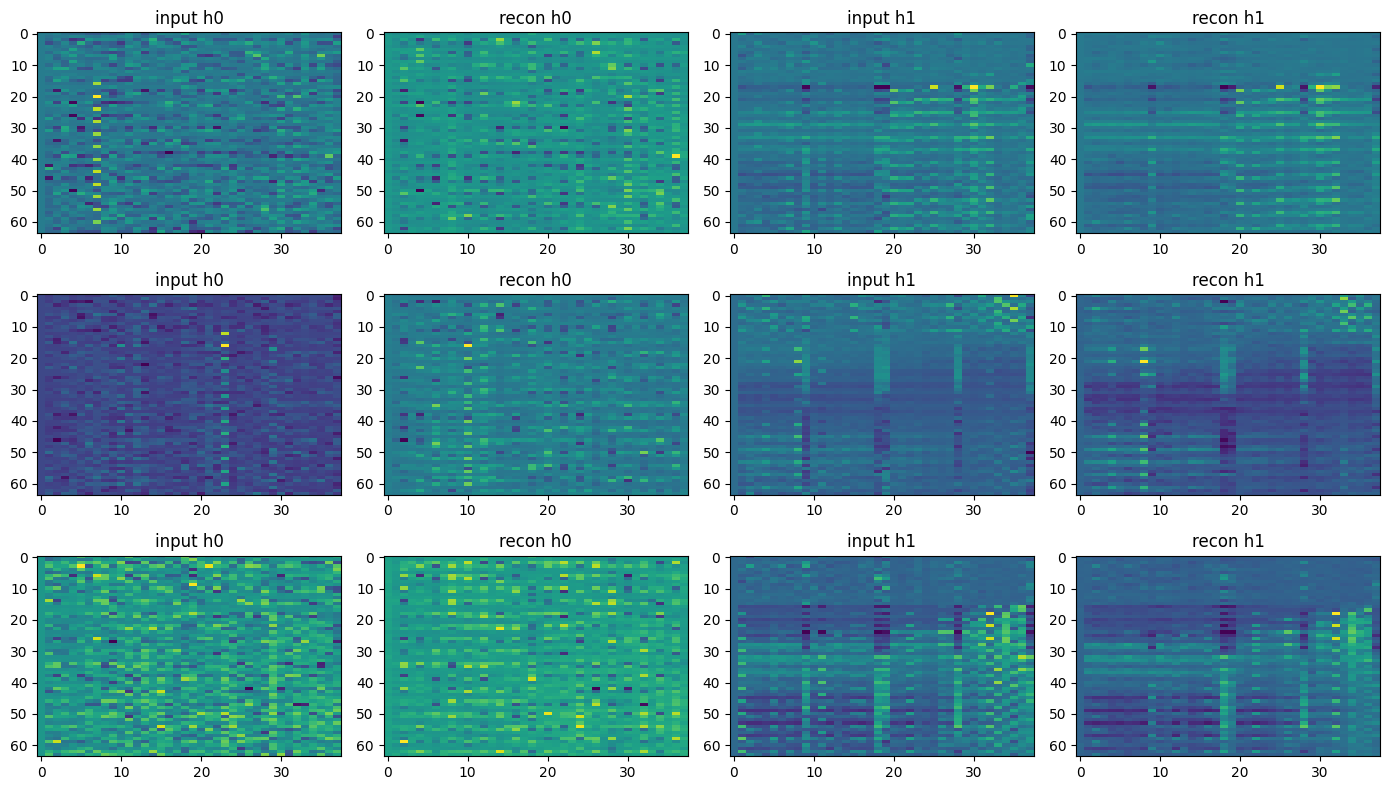

latent shape: torch.Size([256, 16, 16, 10])


In [13]:
model.eval()
with torch.no_grad():
    x = next(iter(val_loader)).to(device)
    x_hat, z = model(x)
x, x_hat = x.cpu().numpy(), x_hat.cpu().numpy()

# show 3 events × (input half 0 | recon half 0 | input half 1 | recon half 1)
fig, ax = plt.subplots(3, 4, figsize=(14, 8))
for row in range(3):
    ax[row, 0].imshow(x[row, 0],     aspect="auto"); ax[row, 0].set_title("input h0")
    ax[row, 1].imshow(x_hat[row, 0], aspect="auto"); ax[row, 1].set_title("recon h0")
    ax[row, 2].imshow(x[row, 1],     aspect="auto"); ax[row, 2].set_title("input h1")
    ax[row, 3].imshow(x_hat[row, 1], aspect="auto"); ax[row, 3].set_title("recon h1")
plt.tight_layout(); plt.show()

print("latent shape:", z.shape)  # (batch, 16, 10, 16) — spatial latent; flatten for downstream feature use

## 13. Does the latent encode something meaningful?

Run all val-set events through the encoder, flatten the latent, then project to 2D with PCA and UMAP. Color the points by per-event scalars (energy, hit count, shower center). If the latent encodes physics, those colors should form gradients or clusters in the projection rather than looking random.


latent matrix: (6594, 2560)
PCA explained variance: 41.51%


/Users/prometheus/Documents/Python/uni-env-3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


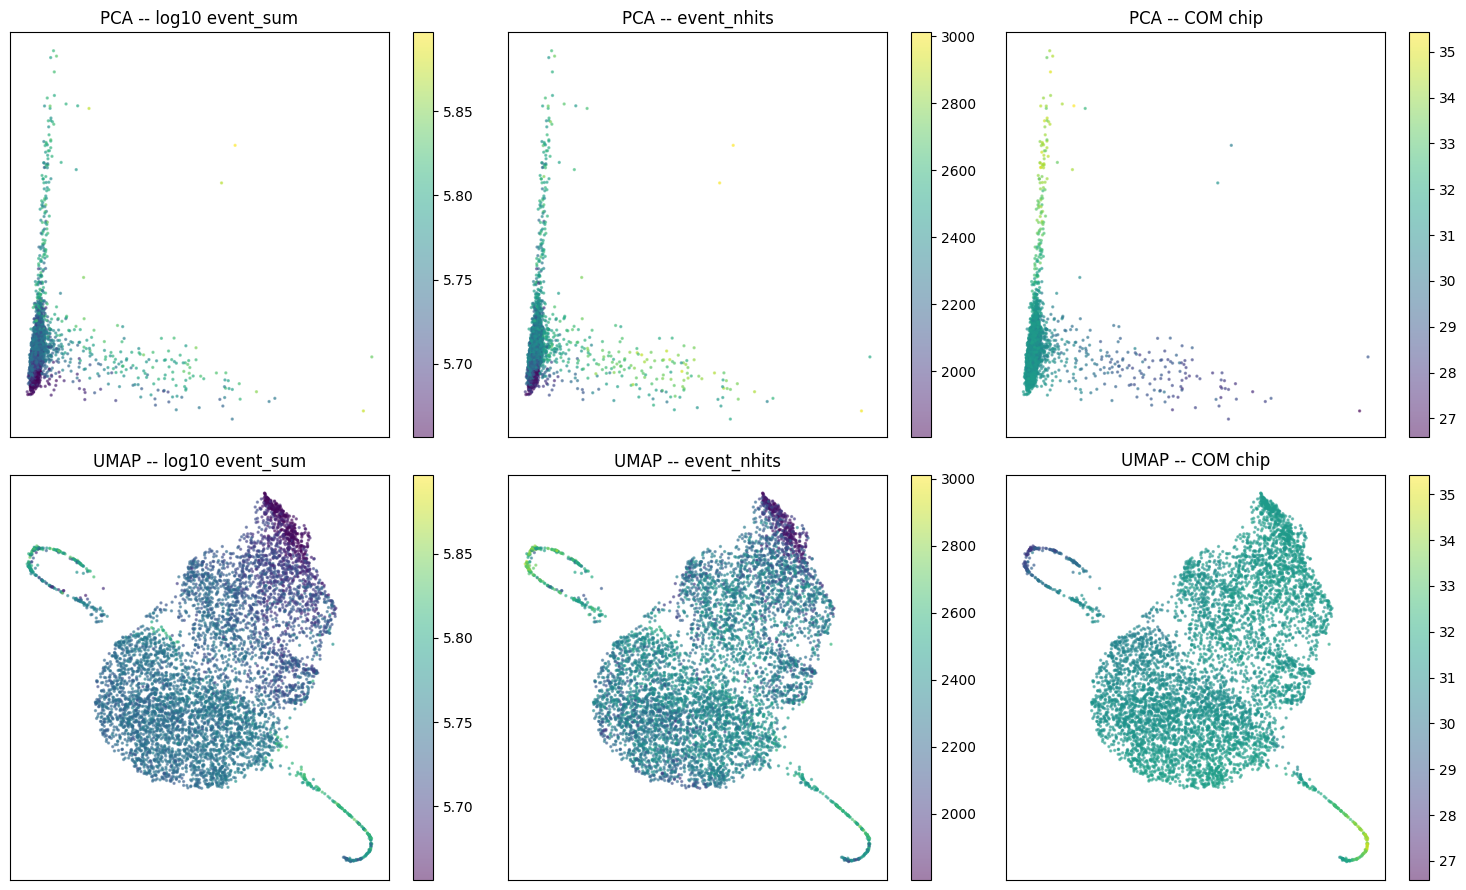

In [14]:
from sklearn.decomposition import PCA
import umap

# 1. Encode all validation events
model.eval()
val_idx = val_ds.indices  # original indices into `ds`
all_lat, all_idx = [], []
loader_full = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0)
with torch.no_grad():
    for x in loader_full:
        x = x.to(device)
        _, z = model(x)
        all_lat.append(z.flatten(1).cpu().numpy())  # (B, 2560)
all_lat = np.concatenate(all_lat, axis=0)
print("latent matrix:", all_lat.shape)

# 2. Pull the event-level scalars aligned to those val events
sum_v   = event_sum[val_idx]
nhits_v = event_nhits[val_idx]
com_v   = com_chip[val_idx]

# 3. Project
pca = PCA(n_components=2).fit_transform(all_lat)
print(f"PCA explained variance: {PCA(n_components=2).fit(all_lat).explained_variance_ratio_.sum():.2%}")
ump = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=0).fit_transform(all_lat)

# 4. Plot: PCA (top row) and UMAP (bottom row), colored by 3 different scalars
def scatter(ax, xy, c, title, log=False):
    if log:
        c = np.log10(np.maximum(c, 1))
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=c, s=2, alpha=0.5, cmap="viridis")
    ax.set_title(title); plt.colorbar(sc, ax=ax)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
scatter(ax[0, 0], pca, sum_v,   "PCA -- log10 event_sum",   log=True)
scatter(ax[0, 1], pca, nhits_v, "PCA -- event_nhits")
scatter(ax[0, 2], pca, com_v,   "PCA -- COM chip")
scatter(ax[1, 0], ump, sum_v,   "UMAP -- log10 event_sum",  log=True)
scatter(ax[1, 1], ump, nhits_v, "UMAP -- event_nhits")
scatter(ax[1, 2], ump, com_v,   "UMAP -- COM chip")
for a in ax.flat: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()


## 14. Confirm the interpretation visually

Cluster the UMAP coordinates with DBSCAN to recover the blob + two arcs automatically, then sample a few events from each cluster and display them as heatmaps. If the story is right, the blob events should look like flat noise and the arc events should show a localized hot region.


eps=1.0: 1 clusters
eps=0.7: 2 clusters

clusters (largest -> smallest):
  cluster 0: n= 6348  mean COM_chip=31.2  mean nhits=2290  mean log10 sum=5.73
  cluster 1: n=  246  mean COM_chip=29.7  mean nhits=2570  mean log10 sum=5.78


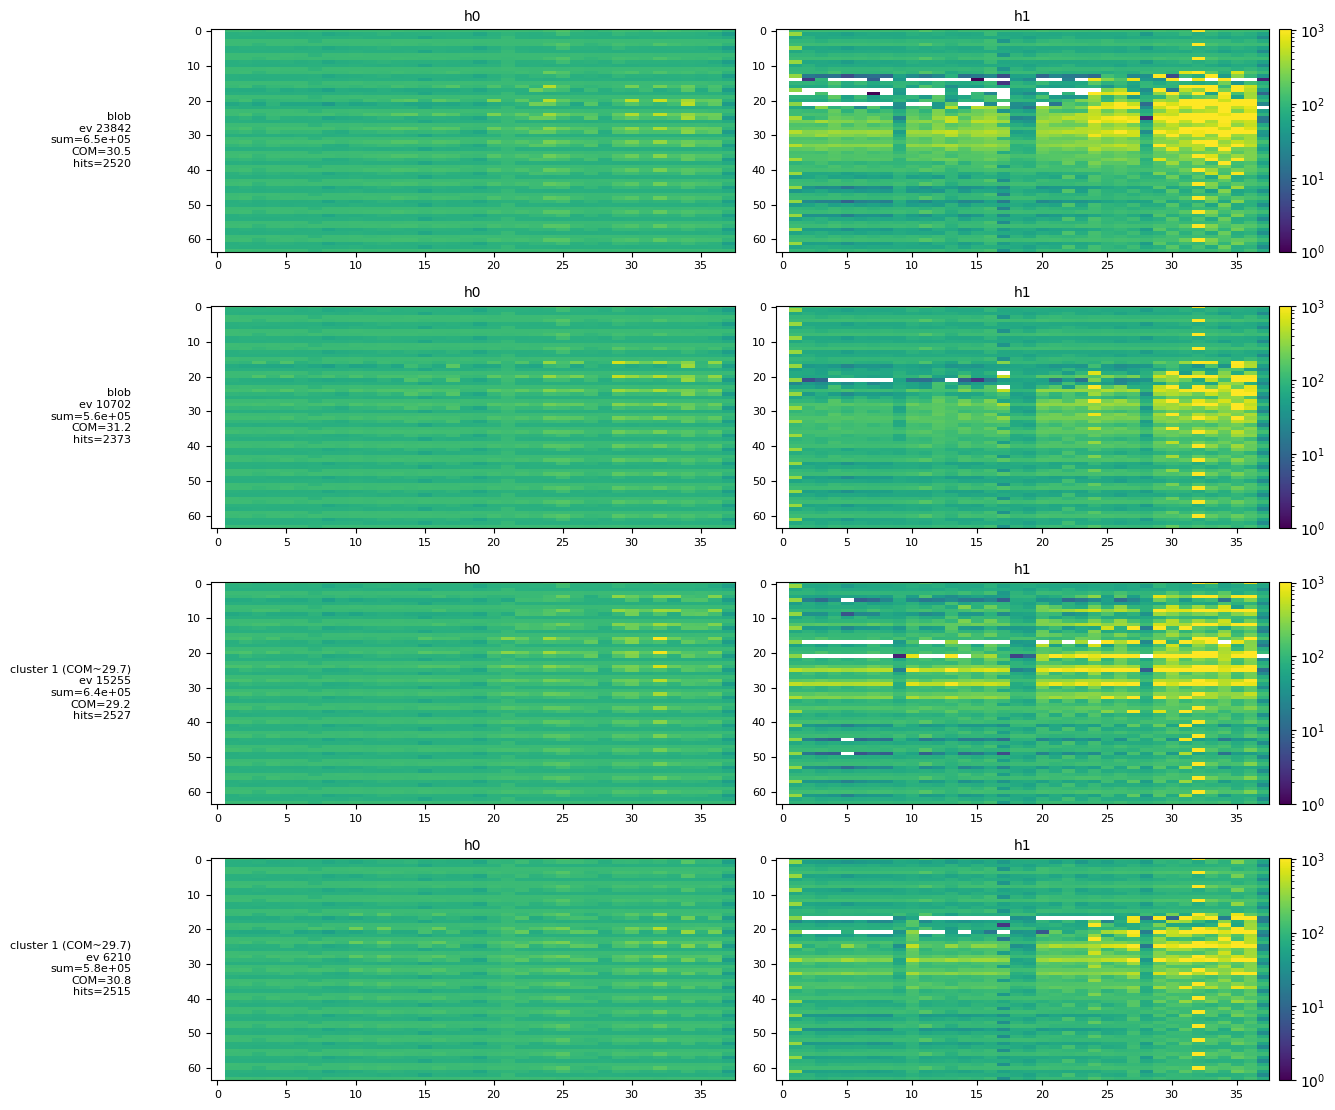

In [15]:
from sklearn.cluster import DBSCAN
from matplotlib.colors import LogNorm

# Tune eps until DBSCAN finds at least 2 well-separated clusters
for eps in (1.0, 0.7, 0.5, 0.3):
    labels = DBSCAN(eps=eps, min_samples=30).fit_predict(ump)
    n_clusters = len([c for c in np.unique(labels) if c != -1])
    print(f"eps={eps}: {n_clusters} clusters")
    if n_clusters >= 2:
        break

clusters = sorted([c for c in np.unique(labels) if c != -1],
                  key=lambda c: -(labels == c).sum())  # largest first
print("\nclusters (largest -> smallest):")
for c in clusters:
    m = labels == c
    print(f"  cluster {c}: n={m.sum():5d}  mean COM_chip={com_v[m].mean():.1f}  "
          f"mean nhits={nhits_v[m].mean():.0f}  mean log10 sum={np.log10(sum_v[m]).mean():.2f}")

def mean_com(c): return com_v[labels == c].mean()
groups = [("blob", clusters[0])]
groups += [(f"cluster {c} (COM~{mean_com(c):.1f})", c)
           for c in sorted(clusters[1:], key=mean_com)]

val_idx_arr = np.asarray(val_idx)
N_PER = 2
rng = np.random.RandomState(0)

n_rows = len(groups) * N_PER
fig, ax = plt.subplots(n_rows, 2, figsize=(13, 2.8 * n_rows), squeeze=False)

for gi, (name, cid) in enumerate(groups):
    members = np.where(labels == cid)[0]
    chosen = rng.choice(members, min(N_PER, len(members)), replace=False)
    for ri, m in enumerate(chosen):
        orig = val_idx_arr[m]
        row = gi * N_PER + ri
        ev = val0[orig]  # (2, 64, 38)

        # log color scale handles huge dynamic range (pedestal ~10s, saturation ~1e5+)
        vmin = 1
        vmax = max(int(np.percentile(ev, 99.5)), 2)
        norm = LogNorm(vmin=vmin, vmax=vmax)

        for h in range(2):
            im = ax[row, h].imshow(ev[h], aspect="auto", cmap="viridis", norm=norm)
            ax[row, h].set_title(f"h{h}", fontsize=10)
            ax[row, h].tick_params(labelsize=8)

        # one shared colorbar per row, placed to the right of h1
        plt.colorbar(im, ax=ax[row, 1], fraction=0.04, pad=0.02)

        # event metadata as the y-label on the h0 panel -- short and out of the title
        ax[row, 0].set_ylabel(
            f"{name}\nev {orig}\nsum={event_sum[orig]:.1e}\n"
            f"COM={com_chip[orig]:.1f}\nhits={event_nhits[orig]}",
            fontsize=8, rotation=0, ha="right", va="center", labelpad=40,
        )

plt.tight_layout()
plt.subplots_adjust(left=0.13)  # room for the y-label metadata
plt.show()
